## Loss Function


Assume an image classifier model with three outputs for classes: panda, cat, dog. Given an image, the model makes a prediction as a probability for each class.

<img src="images/panda_model.png" height="150">

The model is wrongly predicting that the image depicts a cat with a probability of 0.75. In order to correct the model, we first must compute by how much the model is wrong.

In this case the model output is $\begin{bmatrix}0.15\\0.75\\0.1\end{bmatrix}$ and the target, or ground truth, is $\begin{bmatrix}1\\0\\0\end{bmatrix}$

The loss function quantifies how poorly a model is performing, the larger the value the worse the model's prediction.

A loss function is a function that takes two arguments: the ground truth, or target, and the model's output. It measures the discrepancy between the model's output and the ground truth.

loss $ \Bigl( \begin{bmatrix}1\\0\\0\end{bmatrix} , \begin{bmatrix}0.15\\0.75\\0.1\end{bmatrix}  \Bigl) = \dots$



### Mean Squared Error

MSE is one of the simplest loss functions. It computes the average of the squared differences between the predicted output and the ground truth.

$ e = 1/N \times \large\sum_{i=1}^N (gt_i-pred_i)^2$

Where:

- $N$ is the number of data points;
- $gt_i$ is the ground truth for the $i$-th example;
- $pred_i$ is the predicted value for the $i$-th example.

In [20]:
import math
from matplotlib import pyplot as plt
import numpy as np

In [21]:
# this function assumes a single output and therefore does not perform 
# the division by the number of elements


def squared_error(gt, predicted):

    diff = gt - predicted
    return np.mean(diff**2)

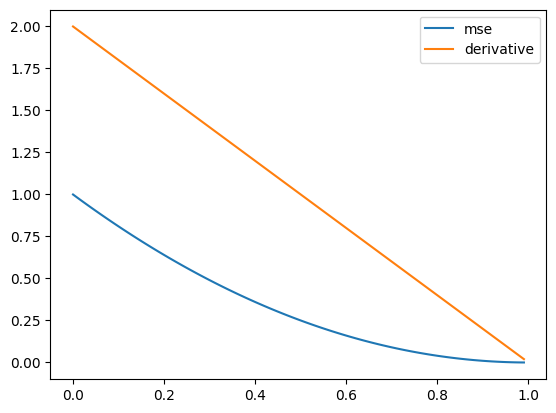

In [22]:
# derivative grows linearly with error magnitude

xx = [k/100 for k in range(100)]

y = [squared_error(1, k) for k in xx]
dy = [2*(1-x) for x in xx]


plt.plot(xx,y, label = 'mse')
plt.plot(xx,dy, label = 'derivative')
plt.legend()
plt.show()

#### torch usage

In [23]:
import torch

loss_fn = torch.nn.MSELoss()
input = torch.randn(2, 4)
target = torch.tensor([[1,0,0,0], [0,1,0,0]])
loss = loss_fn(input, target)
print(input)
print(target)
print(loss)


tensor([[ 0.8516, -1.0067, -1.6384,  0.9513],
        [-1.4795, -0.3963, -1.3784, -0.9427]])
tensor([[1, 0, 0, 0],
        [0, 1, 0, 0]])
tensor(1.4440)


### Cross Entropy Loss

Cross Entropy Loss is commonly used in classification problems, particularly in tasks like binary and multiclass classification.

For binary classification problems, where the output is a probability for the two classes, the Cross Entropy Loss is defined as:

$L = - (y \times log(p) + (1-y) \times log(1-p))$

where $log$ is the natural logrithm (base $e$)

The goal is to have a loss that is small when the model assigns high probability to the correct class, and very large when it assigns low probability.
The function $-\log(p)$ behaves exactly like this: it decreases smoothly when p gets closer to 1 and goes to infinity when p approaches 0.

For binary classification, if the true label is 1 we penalize $-\log(p)$, and if the true label is 0 we penalize $-\log(1-p)$. Combining both in a single formula gives the binary cross-entropy.

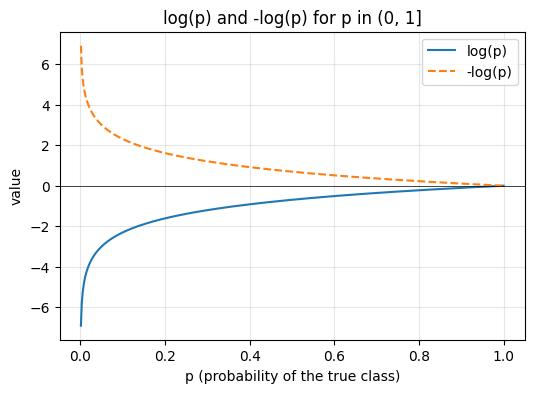

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Probabilities between 0 and 1
p = np.linspace(0.001, 1.0, 500)   # avoid 0 to prevent log(0)
log_p = np.log(p)                  # natural logarithm
neg_log_p = -log_p                 # used in BCE

plt.figure(figsize=(6, 4))

plt.plot(p, log_p, label='log(p)')
plt.plot(p, neg_log_p, label='-log(p)', linestyle='--')

plt.xlabel('p (probability of the true class)')
plt.ylabel('value')
plt.title('log(p) and -log(p) for p in (0, 1]')
plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()


### Categorical Cross Entropy

For multiple classes, the following version is commonly used

$ L =  - \large \sum_i y_i \times log(p_i)$

In [25]:
def categorical_cross_entropy(gt, predicted):

    return  - gt * math.log(1e-8 + predicted)

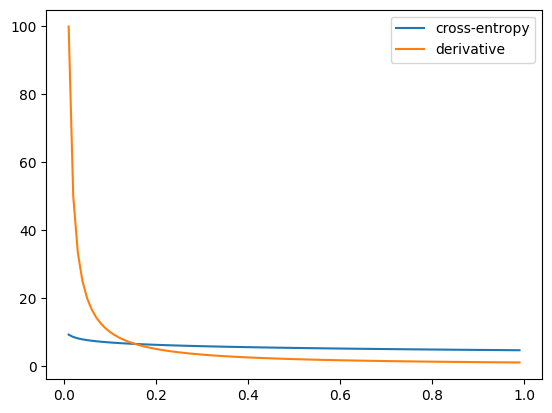

In [26]:
z = [categorical_cross_entropy(1, k/100) for k in xx[1:]]
dz = [1/k for k in xx[1:]]

plt.plot(xx[1:],z, label = 'cross-entropy')
plt.plot(xx[1:],dz, label = 'derivative')
plt.legend()
plt.show()

Compared with MSE, Cross Entropy has higher gradients pushing for large steps when the predicted value is further away ground truth.

### Logits (raw scores)

For a classification problem with $K$ classes, the model outputs a vector
$\mathbf{z} = (z_1, \dots, z_K)$ of logits. We obtain probabilities by
applying the softmax function:

$
p_k = \text{softmax}(\mathbf{z})_k =
\Large \frac{e^{z_k}}{\sum_j e^{z_j}}.
$

In theory, categorical cross-entropy is defined in terms of the predicted
probabilities $p_k$.

In practice, neural networks output **logits** (raw scores) $\mathbf{z}$,
and deep learning libraries apply a numerically stable combination of
softmax and cross-entropy directly on these logits.

In PyTorch, `torch.nn.CrossEntropyLoss` expects logits as input, not
probabilities. Internally it computes `log_softmax` and then the
negative log-likelihood loss, which is mathematically equivalent to
softmax + cross-entropy, but more numerically stable and more efficient.